In [1]:
#!/usr/bin/env python
# -*- encoding: utf-8
import os
import itertools as itools
from dask.distributed import Client, LocalCluster
from dask.distributed import get_client
import xarray as xr
import matplotlib.pyplot as plt

import core_scripts
from core_scripts import *

In [2]:
models = ["NorESM2-MM"]#["IPSL-CM6A-LR"]#["NorESM2-MM"]#
no_members = 3

members = [f"r{r}i1p1f1" for r in range(1, no_members+1)]
# members = ["r1i1p1f1", "r2i1p1f1", "r3i1p1f1"]
experiments = ["historical", "ssp370"]	
# combinations = [
#     f"--{model} --{member} --{experiment}"
#     for model, member, experiment
#         in itools.product(models, members, experiments)]
combinations = [
    dict(zip(["model", "experiment", "member"],[model, experiment, member]))
    for model, experiment, member
        in itools.product(models, experiments, members)]
combinations

[{'model': 'NorESM2-MM', 'experiment': 'historical', 'member': 'r1i1p1f1'},
 {'model': 'NorESM2-MM', 'experiment': 'historical', 'member': 'r2i1p1f1'},
 {'model': 'NorESM2-MM', 'experiment': 'historical', 'member': 'r3i1p1f1'},
 {'model': 'NorESM2-MM', 'experiment': 'ssp370', 'member': 'r1i1p1f1'},
 {'model': 'NorESM2-MM', 'experiment': 'ssp370', 'member': 'r2i1p1f1'},
 {'model': 'NorESM2-MM', 'experiment': 'ssp370', 'member': 'r3i1p1f1'}]

In [3]:
model, experiment, member = combinations[1].values()
model, experiment, member

('NorESM2-MM', 'historical', 'r2i1p1f1')

In [4]:
for combination in combinations[3:4]:
    model, experiment, member = combination.values()
    precursor_projection.run_precursor_projection(
        model, experiment, member, debug=True, overwrite=True, variables=["z500_detrend"])
    client = get_client()
    client.close()

['--model', 'NorESM2-MM', '--experiment', 'ssp370', '--member', 'r1i1p1f1', '--variables', 'z500_detrend', '--seasons', 'DJF', 'MAM', 'JJA', 'SON', '--lags', '0', '--inputdir', '/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/', '--auxdir', '/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/', '--savedir', '/Data/skd/projects/global/cmip6_precursors/outputs/indices/', '--precursorid', 'standard', '--refid', 'ERA5', '--overwrite', '--debug']
Access dask dashboard:  http://127.0.0.1:8787/status

Calling: load_precursor_patterns_and_params with args=(Namespace(model='NorESM2-MM', experiment='ssp370', member='r1i1p1f1', variables=['z500_detrend'], overwrite=True, seasons=['DJF', 'MAM', 'JJA', 'SON'], regions=[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39], lags=[0], inputdir='/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/', auxdir='/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux

In [4]:
test_path = "z500_detrend"
test_path.split("_")[0]

'z500'

In [5]:
path="/Data/skd/projects/global/cmip6_precursors/outputs/indices/NorESM2-LM/z500/historical/member_r1i1p1f1_DJF_region14.nc"
ds = xr.open_dataset(path, decode_cf=False)
ds#.z500_lag0_index_val1.plot()

<xarray.Dataset> Size: 234kB
Dimensions:               (string6: 11, time: 5850)
Coordinates:
  * time                  (time) float64 47kB 7.114e+05 7.114e+05 ... 7.351e+05
Dimensions without coordinates: string6
Data variables: (12/13)
    lag                   int32 4B ...
    region                (string6) |S1 11B ...
    number                int32 4B ...
    region_number         int32 4B ...
    quantile              float64 8B ...
    region_id             int64 8B ...
    ...                    ...
    index_val             int64 8B ...
    plev                  float64 8B ...
    year                  (time) int64 47kB ...
    month                 (time) int64 47kB ...
    dayofyear             (time) int64 47kB ...
    z500_lag0_index_val1  (time) float64 47kB ...

In [6]:
z500 = ds.z500_lag0_index_val1

In [7]:
z500.max()

<xarray.DataArray 'z500_lag0_index_val1' ()> Size: 8B
array(-5.72837987)

In [8]:
index_dir='/Data/skd/projects/global/cmip6_precursors/outputs/indices/'

In [9]:
index_path = index_dir+model+"/z500/"+experiment+"/member_"+member+"_DJF_region14.nc"
index_ds = xr.open_dataset(index_path)
index_ds

<xarray.Dataset> Size: 198kB
Dimensions:               (time: 4950)
Coordinates: (12/13)
    lag                   int32 4B ...
    region                object 8B ...
    number                int32 4B ...
    region_number         int32 4B ...
    quantile              float64 8B ...
    region_id             int64 8B ...
    ...                    ...
    index_val             int64 8B ...
  * time                  (time) object 40kB 1950-01-01 12:00:00 ... 2014-12-...
    plev                  float64 8B ...
    year                  (time) int64 40kB ...
    month                 (time) int64 40kB ...
    dayofyear             (time) int64 40kB ...
Data variables:
    z500_lag0_index_val1  (time) float64 40kB ...

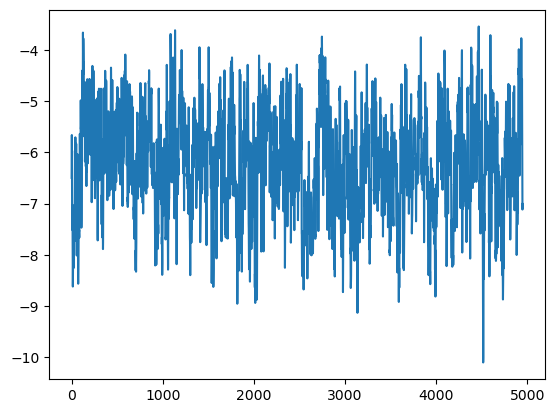

In [10]:
plt.plot(index_ds.z500_lag0_index_val1)

In [11]:
aux_dir="/Data/skd/projects/global/cmip6_precursors/aux/"
pattern_dir=aux_dir+"patterns/"
param_dir=aux_dir+"std_params/"

In [12]:
pattern_path = pattern_dir+"standard_DJF_region11.nc"
param_path = param_dir+"standard_ERA5_DJF_region11.nc"

In [13]:
pattern_ds = xr.open_dataset(pattern_path)
param_ds = xr.open_dataset(param_path)

In [14]:
param_ds.z500_lag0_index_val1.values

array([5.26547959e+06, 6.82054235e+08])

In [15]:
pattern_ds.z500.sel(lag=0, index_val=1)

<xarray.DataArray 'z500' (lat: 71, lon: 161)> Size: 91kB
[11431 values with dtype=float64]
Coordinates:
    number         int64 8B ...
    region_number  int64 8B ...
    region         <U14 56B ...
    quantile       float64 8B ...
    lag            int64 8B 0
  * lat            (lat) float32 284B 15.0 16.0 17.0 18.0 ... 83.0 84.0 85.0
  * lon            (lon) float32 644B -100.0 -99.0 -98.0 ... 58.0 59.0 60.0
    index_val      int64 8B 1
Attributes:
    standard_name:   geopotential
    long_name:       Geopotential
    units:           m**2 s**-2
    is_categorical:  0

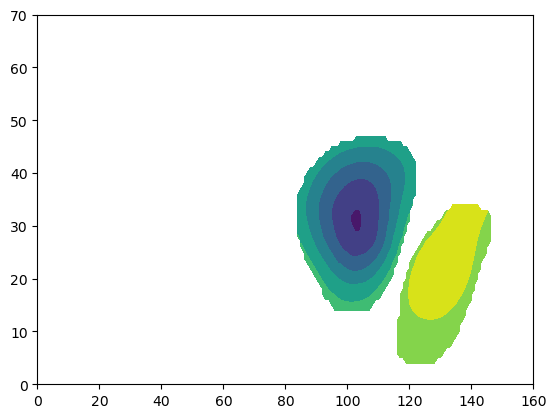

In [16]:
plt.contourf(pattern_ds.z500.sel(lag=0, index_val=1))